# Week 9 Tutorial - Neural Networks

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written - just run it)
- A **DO IT YOURSELF** cell with different data

---

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Breast cancer for examples
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

# Wine for do-it-yourself
wine = load_wine()
X_w, y_w = wine.data, wine.target
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(X_w, y_w, test_size=0.2, random_state=42, stratify=y_w)

print('Cancer dataset:', X_c_train.shape)
print('Wine dataset:  ', X_w_train.shape)

Cancer dataset: (455, 30)
Wine dataset:   (142, 13)


---
## Section 1 - From Logistic Regression to Neural Network
### EXAMPLE

In [6]:
# EXAMPLE: logistic regression vs 1-layer neural network vs 2-layer neural network
# Shows how adding layers improves capacity

scaler = StandardScaler()
X_c_train_scaled = scaler.fit_transform(X_c_train)
X_c_test_scaled  = scaler.transform(X_c_test)

models = [
    ('Logistic Regression',        LogisticRegression(max_iter=1000)),
    ('MLP - 1 hidden layer (32)',   MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=42)),
    ('MLP - 2 hidden layers (64,32)', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    ('MLP - 3 hidden layers (128,64,32)', MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)),
]

print(f'{"Model":<40}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 62)

for name, model in models:
    scores = cross_val_score(model, X_c_train_scaled, y_c_train, cv=5, scoring='accuracy')
    print(f'{name:<40}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

Model                                       CV Acc       Std
--------------------------------------------------------------
Logistic Regression                         0.9802    0.0128
MLP - 1 hidden layer (32)                   0.9758    0.0162
MLP - 2 hidden layers (64,32)               0.9736    0.0204
MLP - 3 hidden layers (128,64,32)           0.9714    0.0179


### DO IT YOURSELF - Section 1
Dataset: wine (3 classes, 13 features)

1. Scale the wine data
2. Compare Logistic Regression vs MLP with 1, 2, and 3 hidden layers
3. Print CV accuracy for each
4. Comment: does adding more layers help on wine?

In [7]:
# DO IT YOURSELF - Section 1
# YOUR CODE HERE
scaler = StandardScaler()
X_w_train_scaled = scaler.fit_transform(X_w_train)
X_w_test_scaled = scaler.transform(X_w_test)

models = [
    ('Logistic Regression',        LogisticRegression(max_iter=1000)),
    ('MLP - 1 hidden layer (32)',   MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=42)),
    ('MLP - 2 hidden layers (64,32)', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    ('MLP - 3 hidden layers (128,64,32)', MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)),
]

print(f'{"Model":<40}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 62)

for name, model in models:
    scores = cross_val_score(model, X_w_train_scaled, y_w_train, cv=5, scoring='accuracy')
    print(f'{name:<40}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

# Not quite. one layer has the best result in terms of accuracy and std
# probably overfitting because data is simple

Model                                       CV Acc       Std
--------------------------------------------------------------
Logistic Regression                         0.9860    0.0172
MLP - 1 hidden layer (32)                   0.9931    0.0138
MLP - 2 hidden layers (64,32)               0.9791    0.0277
MLP - 3 hidden layers (128,64,32)           0.9862    0.0276


---
## Section 2 - Activation Functions
### EXAMPLE

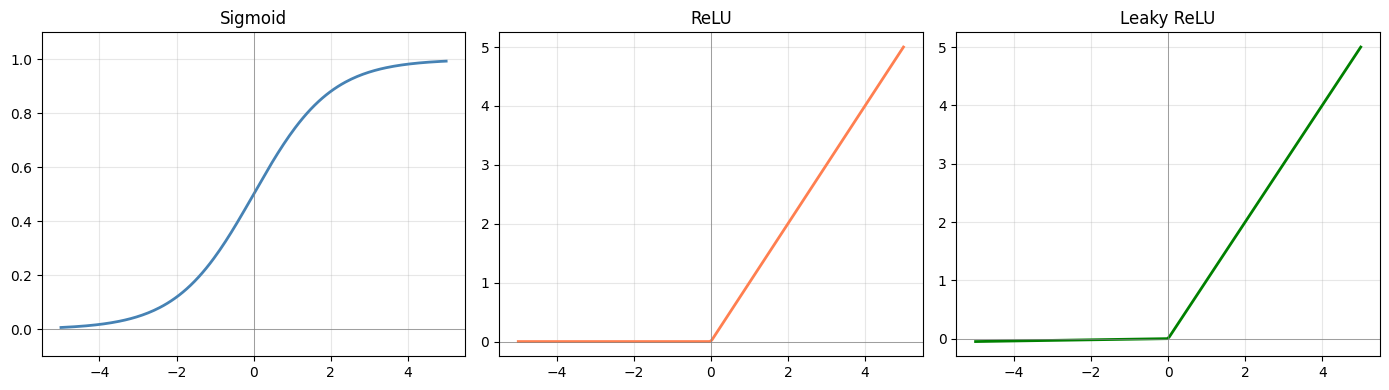

Sigmoid: output 0-1, squashes large values (causes vanishing gradients in deep nets)
ReLU:    output 0+, no squashing for positive values (default for hidden layers)
Leaky:   small slope for negative values (prevents dying ReLU)


In [8]:
# EXAMPLE: visualize activation functions

z = np.linspace(-5, 5, 200)

def sigmoid(z): return 1 / (1 + np.exp(-z))
def relu(z): return np.maximum(0, z)
def leaky_relu(z): return np.where(z > 0, z, 0.01 * z)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(z, sigmoid(z), 'steelblue', lw=2)
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axvline(0, color='gray', lw=0.5)
axes[0].set_title('Sigmoid')
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(alpha=0.3)

axes[1].plot(z, relu(z), 'coral', lw=2)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].axvline(0, color='gray', lw=0.5)
axes[1].set_title('ReLU')
axes[1].grid(alpha=0.3)

axes[2].plot(z, leaky_relu(z), 'green', lw=2)
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].axvline(0, color='gray', lw=0.5)
axes[2].set_title('Leaky ReLU')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Sigmoid: output 0-1, squashes large values (causes vanishing gradients in deep nets)')
print('ReLU:    output 0+, no squashing for positive values (default for hidden layers)')
print('Leaky:   small slope for negative values (prevents dying ReLU)')

In [10]:
# EXAMPLE: compare activation functions on breast cancer

activations = ['logistic', 'relu', 'tanh']

print(f'{"Activation":<12}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 34)

for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(64, 32), activation=act, max_iter=500, random_state=42)
    scores = cross_val_score(model, X_c_train_scaled, y_c_train, cv=5, scoring='accuracy')
    print(f'{act:<12}  {scores.mean():>8.4f}  {scores.std():>8.4f}')


Activation      CV Acc       Std
----------------------------------
logistic        0.9736    0.0112
relu            0.9736    0.0204
tanh            0.9758    0.0189


### DO IT YOURSELF - Section 2
Dataset: wine

1. Compare sigmoid, relu, and tanh on wine with `hidden_layer_sizes=(64, 32)`
2. Print CV accuracy for each
3. Comment: which activation works best and does that match what the study guide says?

In [15]:
# DO IT YOURSELF - Section 2
# YOUR CODE HERE
activations = ['logistic', 'relu', 'tanh']

print(f'{"Activation":<12}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 34)

for act in activations:
    model = MLPClassifier(hidden_layer_sizes=(64, 32), activation=act, max_iter=500, random_state=42)
    scores = cross_val_score(model, X_w_train_scaled, y_w_train, cv=5, scoring='accuracy')
    print(f'{act:<12}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

#tanh performed better, since its a small dataset each data's signal matters. so it might be
# better to use it isntead of logistic and relu if no vanishing gradient is found

Activation      CV Acc       Std
----------------------------------
logistic        0.9791    0.0277
relu            0.9791    0.0277
tanh            0.9860    0.0172


---
## Section 3 - Forward Pass (Manual)
### EXAMPLE

In [16]:
# EXAMPLE: implement a forward pass from scratch (no sklearn)
# 2-layer network for binary classification

np.random.seed(42)

# tiny dataset: 5 samples, 3 features
X = np.array([[0.5, 1.2, -0.3],
               [1.1, -0.5, 0.8],
               [-0.3, 0.7, 1.5],
               [0.9, 0.2, -0.7],
               [-0.5, 1.0, 0.3]])
y = np.array([1, 0, 1, 0, 1])

# network architecture: 3 -> 4 -> 1
input_size  = 3
hidden_size = 4
output_size = 1

# initialize weights randomly
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

print('Shapes:')
print(f'  X:  {X.shape}')
print(f'  W1: {W1.shape}')
print(f'  b1: {b1.shape}')
print(f'  W2: {W2.shape}')
print(f'  b2: {b2.shape}')
print()

# forward pass
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z1 = X @ W1 + b1          # (5,3) @ (3,4) = (5,4)
a1 = relu(z1)              # (5,4)
z2 = a1 @ W2 + b2         # (5,4) @ (4,1) = (5,1)
a2 = sigmoid(z2)           # (5,1) - probabilities

print('Forward pass output shapes:')
print(f'  z1: {z1.shape}')
print(f'  a1: {a1.shape}')
print(f'  z2: {z2.shape}')
print(f'  a2: {a2.shape}')
print()
print('Predictions (probabilities):')
print(a2.flatten().round(4))
print('True labels:')
print(y)

Shapes:
  X:  (5, 3)
  W1: (3, 4)
  b1: (4,)
  W2: (4, 1)
  b2: (1,)

Forward pass output shapes:
  z1: (5, 4)
  a1: (5, 4)
  z2: (5, 1)
  a2: (5, 1)

Predictions (probabilities):
[0.4873 0.497  0.4958 0.4926 0.4952]
True labels:
[1 0 1 0 1]


### DO IT YOURSELF - Section 3

1. Create a network with architecture: 4 inputs -> 6 hidden -> 3 hidden -> 1 output
2. Initialize W1, b1, W2, b2, W3, b3 with appropriate shapes
3. Run a forward pass on this input: `X = np.array([[1.0, -0.5, 0.3, 0.8]])`
4. Print the shape at each step and the final probability output
5. Comment: what does the final number represent?

In [19]:
# DO IT YOURSELF - Section 3
# YOUR CODE HERE
np.random.seed(42)

X = np.array([[1.0, -0.5, 0.3, 0.8]])

input_size = 4
first_hidden_size = 6
second_hiddne_size = 3
output_size = 1

W1 = np.random.randn(input_size, first_hidden_size) * 0.1
b1 = np.zeros(first_hidden_size)
W2 = np.random.randn(first_hidden_size, second_hiddne_size) * 0.1
b2 = np.zeros(second_hiddne_size)
W3 = np.random.randn(second_hiddne_size, output_size) * 0.1
b3 = np.zeros(output_size)

# forward pass
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z1 = X @ W1 + b1
a1 = relu(z1)           
z2 = a1 @ W2 + b2        
a2 = relu(z2)
z3 = a2 @ W3 + b3
a3 = sigmoid(z3)

print('Forward pass output shapes:')
print(f'  z1: {z1.shape}')
print(f'  a1: {a1.shape}')
print(f'  z2: {z2.shape}')
print(f'  a2: {a2.shape}')
print(f'  z3: {z3.shape}')
print(f'  a3: {a3.shape}')
print()
print('Predictions (probabilities):')
print(a3.flatten().round(4))

# Prediction of given input range from [0,1]


Forward pass output shapes:
  z1: (1, 6)
  a1: (1, 6)
  z2: (1, 3)
  a2: (1, 3)
  z3: (1, 1)
  a3: (1, 1)

Predictions (probabilities):
[0.4997]


---
## Section 4 - Backpropagation
### EXAMPLE

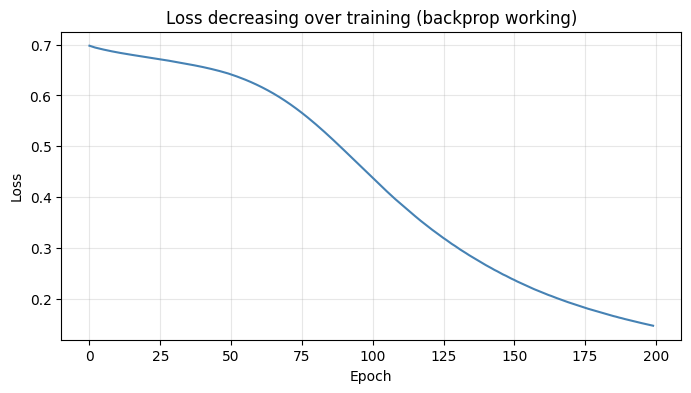

Initial loss: 0.6978
Final loss:   0.1473
Predictions: [1 0 1 0 1]
True labels: [1 0 1 0 1]


In [20]:
# EXAMPLE: implement backprop from scratch on the same 2-layer network
# Watch the loss decrease as weights update

np.random.seed(42)
X = np.array([[0.5, 1.2, -0.3],
               [1.1, -0.5, 0.8],
               [-0.3, 0.7, 1.5],
               [0.9, 0.2, -0.7],
               [-0.5, 1.0, 0.3]])
y = np.array([[1], [0], [1], [0], [1]], dtype=float)

W1 = np.random.randn(3, 4) * 0.1
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1) * 0.1
b2 = np.zeros((1, 1))

lr = 0.1
n = len(X)
loss_history = []

for epoch in range(200):
    # forward pass
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)              # ReLU
    z2 = a1 @ W2 + b2
    a2 = 1 / (1 + np.exp(-z2))         # sigmoid
    
    # loss: binary cross-entropy
    loss = -np.mean(y * np.log(a2 + 1e-8) + (1-y) * np.log(1-a2 + 1e-8))
    loss_history.append(loss)
    
    # backward pass (chain rule)

    dL_da2 = -(y / (a2 + 1e-8)) + (1-y) / (1-a2 + 1e-8)
    da2_dz2 = a2 * (1 - a2)            # sigmoid derivative
    dL_dz2 = dL_da2 * da2_dz2
    
    dL_dW2 = a1.T @ dL_dz2 / n
    dL_db2 = np.mean(dL_dz2, axis=0, keepdims=True)
    
    dL_da1 = dL_dz2 @ W2.T
    dL_dz1 = dL_da1 * (z1 > 0)         # ReLU derivative
    
    dL_dW1 = X.T @ dL_dz1 / n
    dL_db1 = np.mean(dL_dz1, axis=0, keepdims=True)
    
    # update weights
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

plt.figure(figsize=(8, 4))
plt.plot(loss_history, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss decreasing over training (backprop working)')
plt.grid(alpha=0.3)
plt.show()

print(f'Initial loss: {loss_history[0]:.4f}')
print(f'Final loss:   {loss_history[-1]:.4f}')

final_preds = (a2 > 0.5).astype(int).flatten()
print(f'Predictions: {final_preds}')
print(f'True labels: {y.flatten().astype(int)}')

### DO IT YOURSELF - Section 4

1. Run the backprop example above but change `lr` to 0.01, 0.5, and 2.0
2. Plot all 3 loss curves on the same chart with different colors
3. Comment: what happens at lr=2.0 and why?

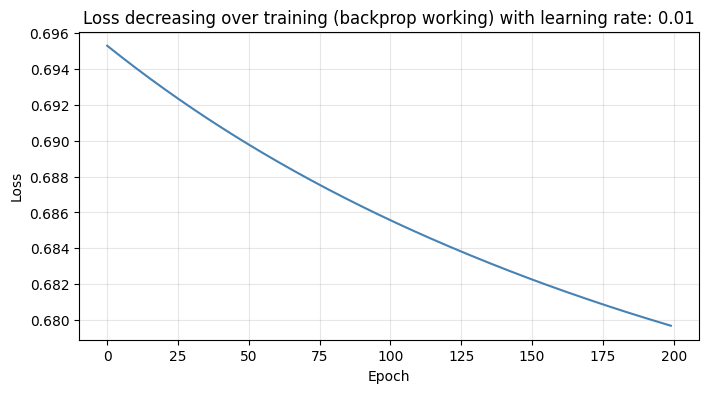

Initial loss: 0.6953
Final loss:   0.6797
Predictions: [1 1 1 1 1]
True labels: [1 0 1 0 1]


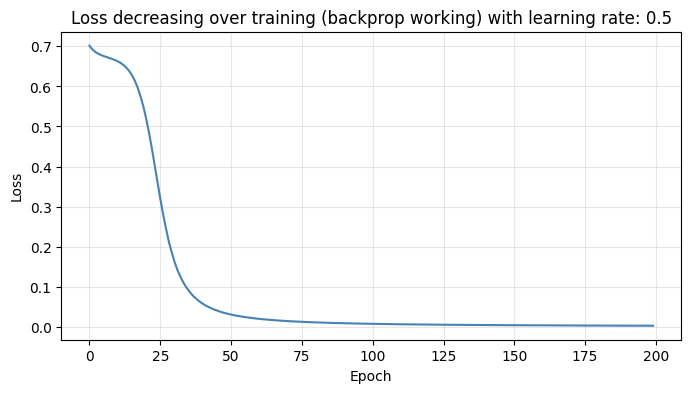

Initial loss: 0.7016
Final loss:   0.0024
Predictions: [1 0 1 0 1]
True labels: [1 0 1 0 1]


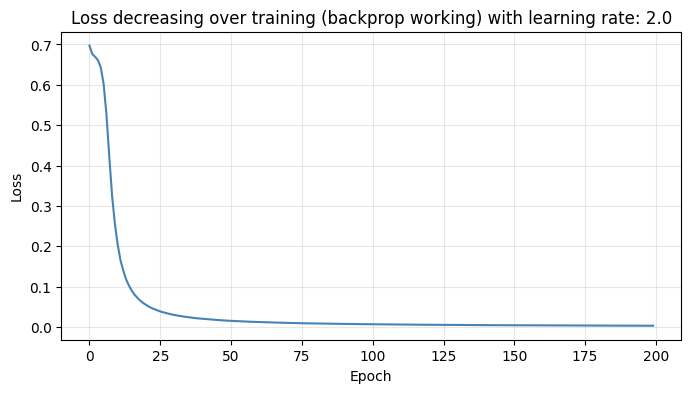

Initial loss: 0.6967
Final loss:   0.0031
Predictions: [1 0 1 0 1]
True labels: [1 0 1 0 1]


In [24]:
# DO IT YOURSELF - Section 4
# YOUR CODE HERE
np.random.seed(42)

def neural_network(learning_rate):
    X = np.array([[0.5, 1.2, -0.3],
               [1.1, -0.5, 0.8],
               [-0.3, 0.7, 1.5],
               [0.9, 0.2, -0.7],
               [-0.5, 1.0, 0.3]])
    y = np.array([[1], [0], [1], [0], [1]], dtype=float)

    W1 = np.random.randn(3, 4) * 0.1
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.1
    b2 = np.zeros((1, 1))

    W1 = np.random.randn(3, 4) * 0.1
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 0.1
    b2 = np.zeros((1, 1))

    lr = learning_rate
    n = len(X)
    loss_history = []

    for epoch in range(200):
        # forward pass
        z1 = X @ W1 + b1
        a1 = np.maximum(0, z1)              # ReLU
        z2 = a1 @ W2 + b2
        a2 = 1 / (1 + np.exp(-z2))         # sigmoid
        
        # loss: binary cross-entropy
        loss = -np.mean(y * np.log(a2 + 1e-8) + (1-y) * np.log(1-a2 + 1e-8))
        loss_history.append(loss)

        # backward pass (chain rule)

        dL_da2 = -(y / (a2 + 1e-8)) + (1-y) / (1-a2 + 1e-8)
        da2_dz2 = a2 * (1 - a2)            # sigmoid derivative
        dL_dz2 = dL_da2 * da2_dz2
        
        dL_dW2 = a1.T @ dL_dz2 / n
        dL_db2 = np.mean(dL_dz2, axis=0, keepdims=True)
        
        dL_da1 = dL_dz2 @ W2.T
        dL_dz1 = dL_da1 * (z1 > 0)         # ReLU derivative
        
        dL_dW1 = X.T @ dL_dz1 / n
        dL_db1 = np.mean(dL_dz1, axis=0, keepdims=True)

        # update weights
        W2 -= lr * dL_dW2
        b2 -= lr * dL_db2
        W1 -= lr * dL_dW1
        b1 -= lr * dL_db1

    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, 'steelblue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss decreasing over training (backprop working) with learning rate: {learning_rate}')
    plt.grid(alpha=0.3)
    plt.show()

    print(f'Initial loss: {loss_history[0]:.4f}')
    print(f'Final loss:   {loss_history[-1]:.4f}')

    final_preds = (a2 > 0.5).astype(int).flatten()
    print(f'Predictions: {final_preds}')
    print(f'True labels: {y.flatten().astype(int)}')

for lr in [0.01, 0.5, 2.0]:
    neural_network(lr)

# At learing rate: 2, we  see loss flattening at much earlier epoch, but final loss is not greater than when lr is 0.5
# difference is minor 

---
## Section 5 - Training with MLPClassifier
### EXAMPLE

In [25]:
# EXAMPLE: effect of hidden layer size and depth on breast cancer

architectures = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
]

print(f'{"Architecture":<25}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 48)

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation='relu', max_iter=500, random_state=42)
    scores = cross_val_score(model, X_c_train_scaled, y_c_train, cv=5, scoring='accuracy')
    print(f'{str(arch):<25}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

Architecture                 CV Acc       Std
------------------------------------------------
(32,)                        0.9758    0.0162
(64,)                        0.9802    0.0213
(128,)                       0.9780    0.0231
(64, 32)                     0.9736    0.0204
(128, 64)                    0.9714    0.0215
(128, 64, 32)                0.9714    0.0179


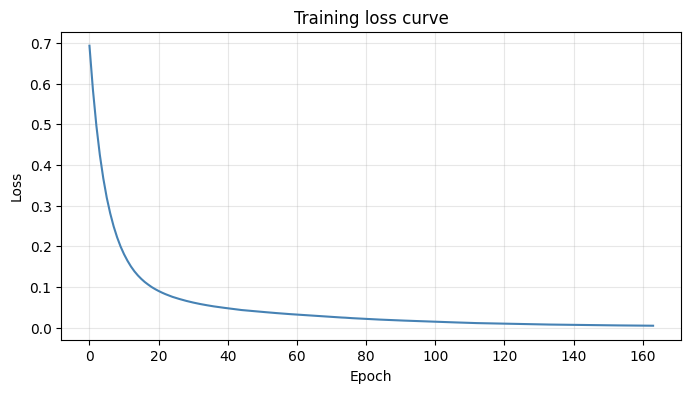

              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [26]:
# EXAMPLE: watch loss curve during training using loss_curve_ attribute

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42
)
model.fit(X_c_train_scaled, y_c_train)

plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss curve')
plt.grid(alpha=0.3)
plt.show()

print(classification_report(y_c_test, model.predict(X_c_test_scaled), target_names=cancer.target_names))

### DO IT YOURSELF - Section 5
Dataset: wine

1. Try 4 different architectures on the wine dataset
2. Print CV accuracy for each
3. Train the best architecture and plot its loss curve
4. Print classification report on test set
5. Comment: how does the best MLP compare to Random Forest from week 6?

In [27]:
# DO IT YOURSELF - Section 5
# YOUR CODE HERE
architectures = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
]

print(f'{"Architecture":<25}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 48)

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, activation='relu', max_iter=500, random_state=42)
    scores = cross_val_score(model, X_w_train_scaled, y_w_train, cv=5, scoring='accuracy')
    print(f'{str(arch):<25}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

# Compared to Random search tree it actually performed about the same (CV accuracy: 0.9931)

Architecture                 CV Acc       Std
------------------------------------------------
(32,)                        0.9931    0.0138
(64,)                        0.9931    0.0138
(128,)                       0.9860    0.0172
(64, 32)                     0.9791    0.0277
(128, 64)                    0.9931    0.0138
(128, 64, 32)                0.9862    0.0276


---
## Section 6 - Neural Network vs Classical ML
### EXAMPLE

Model                             CV Acc       Std
----------------------------------------------------
Logistic Regression               0.9802    0.0128
Random Forest                     0.9538    0.0235
MLP (64,32)                       0.9780    0.0155
MLP (128,64,32)                   0.9692    0.0213


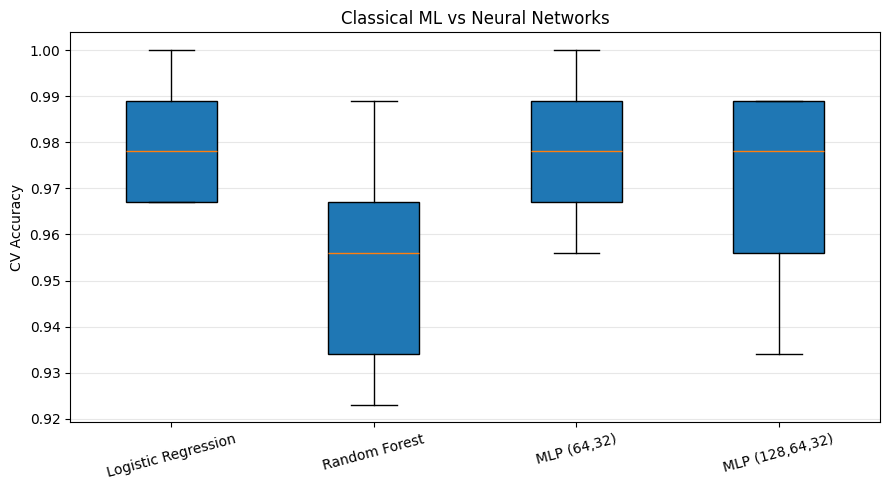

In [29]:
# EXAMPLE: full comparison - classical ML vs neural network on breast cancer

models = [
    ('Logistic Regression', Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('MLP (64,32)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))])),
    ('MLP (128,64,32)',     Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42))])),
]

print(f'{"Model":<30}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 52)

results = {}
for name, model in models:
    scores = cross_val_score(model, X_c_train, y_c_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<30}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(results.values(), tick_labels=results.keys(), patch_artist=True)
ax.set_ylabel('CV Accuracy')
ax.set_title('Classical ML vs Neural Networks')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### DO IT YOURSELF - Section 6
Dataset: wine

1. Run the full comparison (LogReg, RF, 2 MLP architectures) on wine
2. Print CV accuracy table and boxplot
3. Comment: on tabular data like wine, does the neural network beat classical ML?
   Why or why not?

In [31]:
# DO IT YOURSELF - Section 6
# YOUR CODE HERE
models = [
    ('Logistic Regression', Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42)),
    ('MLP (64,32)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))])),
    ('MLP (128,64,32)',     Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42))])),
]

print(f'{"Model":<30}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 52)

results = {}
for name, model in models:
    scores = cross_val_score(model, X_w_train, y_w_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<30}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

# No actually Logistic Regression perfomed better. When data is simple probably best to choose simpler model

Model                             CV Acc       Std
----------------------------------------------------
Logistic Regression               0.9931    0.0138
Random Forest                     0.9862    0.0276
MLP (64,32)                       0.9791    0.0277
MLP (128,64,32)                   0.9862    0.0276


---
## CAPSTONE

1. Load the breast cancer dataset
2. Find the best MLP architecture using cross-validation (try at least 6 architectures)
3. Compare best MLP vs best classical model from week 6 (Random Forest)
4. Train final model on full training set, evaluate on test set
5. Plot the loss curve
6. Plot confusion matrix
7. Written answer: on tabular data, when would you choose a neural network over Random Forest?

Model                             CV Acc       Std
----------------------------------------------------
MLP (8,)                          0.9824    0.0215
MLP (16,)                         0.9780    0.0139
MLP (32,)                         0.9780    0.0184
MLP (64,)                         0.9802    0.0213
MLP (64,32)                       0.9780    0.0155
MLP (128,64,32)                   0.9692    0.0213


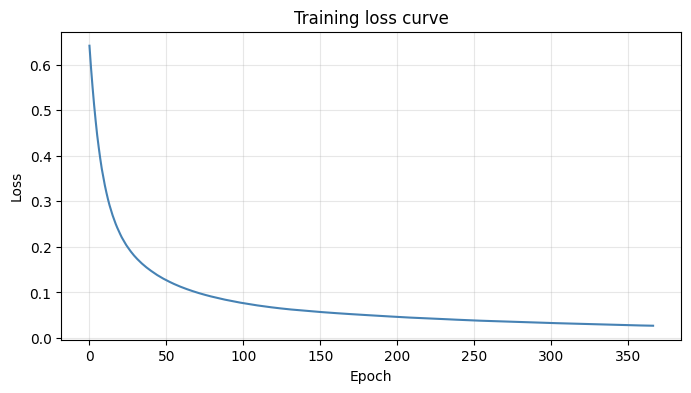

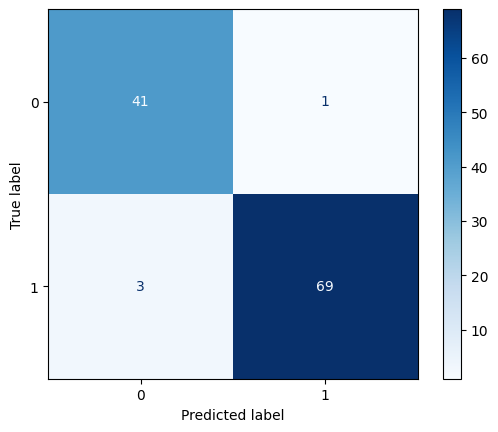

In [ ]:
# CAPSTONE
# YOUR CODE HERE

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = [
    ('MLP (8,)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(8,), max_iter=500, random_state=42))])),
    ('MLP (16,)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42))])),
    ('MLP (32,)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(32,), max_iter=500, random_state=42))])),
    ('MLP (64,)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(64,), max_iter=500, random_state=42))])),
    ('MLP (64,32)',         Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))])),
    ('MLP (128,64,32)',     Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42))]))
]

print(f'{"Model":<30}  {"CV Acc":>8}  {"Std":>8}')
print('-' * 52)

results = {}
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = scores
    print(f'{name:<30}  {scores.mean():>8.4f}  {scores.std():>8.4f}')

# Choosing MLP (16,) here. While its not the best accuracy but difference in accuracy in these models are quite minimal. So choosing best STD

best_pipe =  Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42))])
best_pipe.fit(X_train, y_train)

plt.figure(figsize=(8, 4))
plt.plot(best_pipe.named_steps['model'].loss_curve_, 'steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss curve')
plt.grid(alpha=0.3)
plt.show()


y_pred = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# On tabular data, I would personally choose random forest. especially when doing classification
# This is because usually this is straightforward question like  just need to know what combination of range
# would contribute to certain classification. So simpler model like random forest would work be sufficient
